# Downlink Latency Validation: NOAA-20

TAT-C's latency analysis finds when a satellite can downlink its observations to ground stations (`collect_downlinks`, from the periods each station sees the satellite above its minimum elevation angle) and pairs each observation with the first downlink after it (`compute_latencies`). This notebook compares these with the operational data flow of NOAA-20, the first Joint Polar Satellite System (JPSS) satellite, which records its observations and plays them back to polar ground stations once per half orbit. The National Oceanic and Atmospheric Administration (NOAA) publishes each product granule with its observation start and end times and the time it was created, after its data was downlinked and processed, so the data flow can be reconstructed from the published file names alone. The comparison asks:

1. **Ground station contacts.** Which ground stations does NOAA-20 downlink to, and do TAT-C's predicted contacts with them explain when granules are created?
2. **Downlink timing.** When, within a contact, are granules created?
3. **Latency.** Does `compute_latencies` reproduce the latency from observation to downlink?

## Reference Data

The Advanced Technology Microwave Sounder (ATMS) sensor data record (SDR) granules of NOAA-20 for 3 October 2026 are listed from NOAA's open data bucket on Amazon Web Services (`noaa-nesdis-n20-pds`, anonymous access; only file names are read). Each name gives the granule's observation start and end times (`_t`, `_e`, in UTC, about 32 s per granule) and creation time (`_c`). Granules observed on 3 October are listed from the folders of 3 and 4 October, since folders are organized by observation date. NOAA-20 is modeled with its CelesTrak two-line element (TLE) set (epoch 4 October 2026), cached in a local `data/orbits` directory.

In [1]:
import re
import xml.etree.ElementTree as ET
from datetime import datetime, timedelta, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import requests

DATA_DIR = Path("data") / "latency"
ORBIT_DIR = Path("data") / "orbits"
DATA_DIR.mkdir(parents=True, exist_ok=True)
ORBIT_DIR.mkdir(parents=True, exist_ok=True)
DAY = datetime(2026, 10, 3, tzinfo=timezone.utc)
BUCKET = "https://noaa-nesdis-n20-pds.s3.amazonaws.com/"
GRANULES_FILE = DATA_DIR / f"atms_sdr_granules_{DAY:%Y%m%d}.csv"


def listing(prefix):
    """Object keys under a prefix of the bucket."""
    keys, token = [], None
    namespace = {"s": "http://s3.amazonaws.com/doc/2006-03-01/"}
    while True:
        params = {"list-type": "2", "prefix": prefix}
        if token:
            params["continuation-token"] = token
        response = requests.get(BUCKET, params=params, timeout=120)
        response.raise_for_status()
        root = ET.fromstring(response.content)
        keys += [c.find("s:Key", namespace).text for c in root.findall("s:Contents", namespace)]
        following = root.find("s:NextContinuationToken", namespace)
        if following is None:
            return keys
        token = following.text


if not GRANULES_FILE.exists():
    pattern = re.compile(r"_d(\d{8})_t(\d{7})_e(\d{7})_b(\d+)_c(\d{14})")
    rows = []
    for day in [DAY, DAY + timedelta(days=1)]:
        for key in listing(f"ATMS-SDR/{day:%Y/%m/%d}/"):
            date, start, end, orbit, created = pattern.search(key).groups()
            rows.append({"date": date, "start": start, "end": end, "orbit": int(orbit), "created": created})
    pd.DataFrame(rows).to_csv(GRANULES_FILE, index=False)
granules = pd.read_csv(GRANULES_FILE, dtype=str)
parse = lambda date, clock: pd.to_datetime(date + clock.str[:6], format="%Y%m%d%H%M%S", utc=True)
granules["start"] = parse(granules.date, granules.start)
granules["end"] = parse(granules.date, granules.end)
granules.loc[granules.end < granules.start, "end"] += pd.Timedelta(days=1)
granules["created"] = pd.to_datetime(granules.created, format="%Y%m%d%H%M%S", utc=True)
granules = granules.drop_duplicates("start").sort_values("end")
granules = granules[(granules.end >= DAY) & (granules.end < DAY + timedelta(days=1))].reset_index(drop=True)
granules["latency (min)"] = (granules.created - granules.end).dt.total_seconds() / 60
TLE_FILE = ORBIT_DIR / "weather.tle"
if not TLE_FILE.exists():
    TLE_FILE.write_text(requests.get("https://celestrak.org/NORAD/elements/gp.php", params={"GROUP": "weather", "FORMAT": "tle"}, timeout=120).text)
lines = [line.rstrip() for line in TLE_FILE.read_text().splitlines() if line.strip()]
k = next(i for i, line in enumerate(lines) if line.startswith("NOAA 20"))
TLE = lines[k + 1 : k + 3]
pd.concat([pd.Series({"granules": len(granules), "orbits": granules.orbit.nunique()}), granules["latency (min)"].describe(percentiles=[0.05, 0.5, 0.95])[1:]]).round(1)

granules    2700.0
orbits        15.0
mean          23.1
std           11.9
min            2.8
5%             6.4
50%           22.1
95%           42.8
max           53.2
dtype: float64

## Setup

Contacts are predicted with `collect_downlinks` for five candidate polar ground stations, each with a 5 deg minimum elevation angle: the Svalbard Satellite Station (Norway), McMurdo Ground Station (Antarctica), TrollSat (Antarctica), Fairbanks (Alaska), and Inuvik (Canada).

In [2]:
import matplotlib.pyplot as plt

from tatc.analysis import collect_downlinks, compute_latencies
from tatc.schemas import GeneralPerturbationsOrbit, GroundStation, Satellite

noaa20 = Satellite(name="NOAA 20", orbit=GeneralPerturbationsOrbit.from_tle(TLE))
STATIONS = {
    "Svalbard": (78.23, 15.39),
    "McMurdo": (-77.84, 166.67),
    "Troll": (-72.01, 2.53),
    "Fairbanks": (64.86, -147.85),
    "Inuvik": (68.40, -133.50),
}
stations = {name: GroundStation(name=name, latitude=lat, longitude=lon, min_elevation_angle=5) for name, (lat, lon) in STATIONS.items()}
contacts = {name: collect_downlinks(station, noaa20, DAY - timedelta(hours=3), DAY + timedelta(days=1, hours=3)) for name, station in stations.items()}
BLUE, ORANGE, AQUA, GRAY, INK, PURPLE = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984", "#0b0b0b", "#8e5bd8"
STATION_COLORS = dict(zip(STATIONS, [BLUE, ORANGE, AQUA, PURPLE, GRAY]))
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6})


def downlinking_contact(station_names):
    """For each granule, the first contact (of the given stations) that has not ended when the granule's observation ends."""
    c = pd.concat([contacts[name] for name in station_names]).sort_values("end").reset_index(drop=True)
    return pd.merge_asof(
        granules.sort_values("end"),
        c[["station", "start", "end"]].rename(columns={"start": "contact start", "end": "contact end"}).sort_values("contact end"),
        left_on="end",
        right_on="contact end",
        direction="forward",
    )


pd.DataFrame(
    {
        name: {
            "contacts on 3 October": int(((c.start >= DAY) & (c.start < DAY + timedelta(days=1))).sum()),
            "duration, median (min)": ((c.end - c.start).dt.total_seconds() / 60).median(),
        }
        for name, c in contacts.items()
    }
).T.round(1)

,contacts on 3 October,"duration, median (min)"
Svalbard,15.0,12.0
McMurdo,14.0,11.8
Troll,11.0,12.5
Fairbanks,10.0,11.5
Inuvik,10.0,12.0


## Test 1: Ground Station Contacts

If NOAA-20 plays back its recorded data during contacts with a set of stations, each granule is created shortly after the start of the first contact that has not ended when its observation ends (data observed during a contact is played back in it). For each candidate set of stations, the time from the start of that contact to the granule's creation is computed; the set that NOAA-20 uses should explain nearly all granules with a short, consistent delay.

In [3]:
SETS = [["Svalbard"], ["Svalbard", "McMurdo"], ["Svalbard", "McMurdo", "Troll"], ["Svalbard", "McMurdo", "Fairbanks"], ["Svalbard", "McMurdo", "Troll", "Fairbanks", "Inuvik"]]
rows1 = {}
for station_set in SETS:
    merged = downlinking_contact(station_set)
    delay = (merged.created - merged["contact start"]).dt.total_seconds() / 60
    rows1[" + ".join(station_set)] = {
        "created 0 to 20 min after contact start (%)": 100 * np.mean((delay >= 0) & (delay <= 20)),
        "created before contact start (%)": 100 * np.mean(delay < 0),
        "delay after contact start, median (min)": np.median(delay),
        "delay after contact start, p90 (min)": np.percentile(delay, 90),
    }
pd.DataFrame(rows1).T.round(1)

,created 0 to 20 min after contact start (%),created before contact start (%),"delay after contact start, median (min)","delay after contact start, p90 (min)"
Svalbard,49.3,48.3,2.6,11.6
Svalbard + McMurdo,95.6,0.0,6.3,15.5
Svalbard + McMurdo + Troll,92.3,0.0,7.0,16.5
Svalbard + McMurdo + Fairbanks,92.5,0.0,7.3,16.8
Svalbard + McMurdo + Troll + Fairbanks + Inuvik,88.7,0.0,11.1,23.9


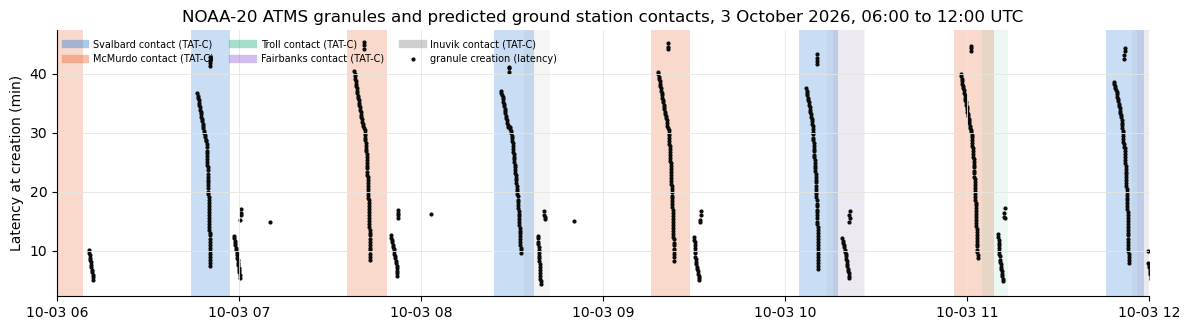

In [4]:
merged = downlinking_contact(["Svalbard", "McMurdo"])
fig, ax = plt.subplots(figsize=(12, 3.4))
window = (DAY + timedelta(hours=6), DAY + timedelta(hours=12))
for name in STATIONS:
    for _, c in contacts[name].iterrows():
        if c.end > window[0] and c.start < window[1]:
            ax.axvspan(c.start, c.end, ymin=0, ymax=1, color=STATION_COLORS[name], alpha=0.25 if name in ("Svalbard", "McMurdo") else 0.08, lw=0)
    ax.plot([], [], color=STATION_COLORS[name], lw=6, alpha=0.4, label=f"{name} contact (TAT-C)")
shown = granules[(granules.end > window[0]) & (granules.end < window[1])]
ax.scatter(shown.created, (shown.created - shown.end).dt.total_seconds() / 60, s=4, color=INK, label="granule creation (latency)")
ax.set(xlim=window, ylabel="Latency at creation (min)", title="NOAA-20 ATMS granules and predicted ground station contacts, 3 October 2026, 06:00 to 12:00 UTC")
ax.legend(frameon=False, fontsize=7, ncol=3, loc="upper left")
fig.tight_layout()
plt.show()

With contacts at Svalbard and McMurdo, every granule is created after the start of a predicted contact (none before), and 96% within 20 minutes of it. With Svalbard alone, half the granules would be created before their contact; adding Troll, Fairbanks, or Inuvik attributes granules to contacts NOAA-20 does not use, and fewer are created within 20 minutes of them. NOAA-20 thus plays back its recorded data at the Svalbard and McMurdo ground stations, once each per orbit (15 and 14 contacts on 3 October), and TAT-C's contacts with them, about 12 minutes long, bracket the creation of the granules (figure: the granules created during each predicted contact, with latencies decreasing from about 40 to 8 minutes, are the data recorded since the previous contact).

## Test 2: Downlink Timing

For the Svalbard and McMurdo contacts, the delay from the contact's start to each granule's creation is examined, together with the order in which a contact's granules are created.

In [5]:
merged["delay (min)"] = (merged.created - merged["contact start"]).dt.total_seconds() / 60
merged["contact duration (min)"] = (merged["contact end"] - merged["contact start"]).dt.total_seconds() / 60
merged["observed during contact"] = merged.end >= merged["contact start"]
rows2 = {}
for label, subset in [("all granules", merged), ("observed before the contact", merged[~merged["observed during contact"]]), ("observed during the contact", merged[merged["observed during contact"]])]:
    rows2[label] = {
        "granules": len(subset),
        "delay after contact start, p10 (min)": subset["delay (min)"].quantile(0.1),
        "delay after contact start, median (min)": subset["delay (min)"].median(),
        "delay after contact start, p90 (min)": subset["delay (min)"].quantile(0.9),
        "created after contact end (%)": 100 * np.mean(subset.created > subset["contact end"]),
    }
pd.DataFrame(rows2).T.round(1)

,granules,"delay after contact start, p10 (min)","delay after contact start, median (min)","delay after contact start, p90 (min)",created after contact end (%)
all granules,2700.0,3.5,6.3,15.5,26.6
observed before the contact,2090.0,3.2,5.9,7.4,5.2
observed during the contact,610.0,10.3,15.0,55.1,100.0


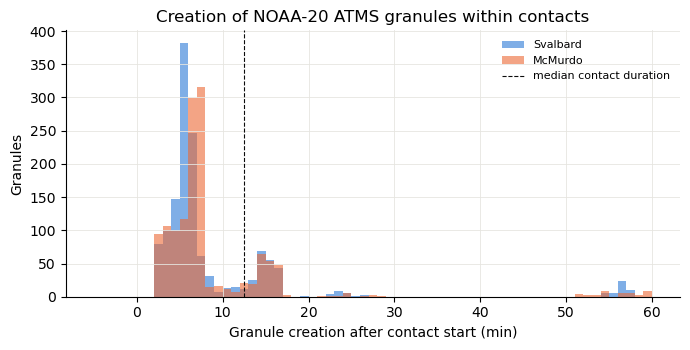

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.6))
for station, color in [("Svalbard", BLUE), ("McMurdo", ORANGE)]:
    s = merged[merged.station == station]
    ax.hist(s["delay (min)"].clip(-5, 60), bins=np.arange(-5, 61, 1), color=color, alpha=0.6, label=station)
ax.axvline(merged["contact duration (min)"].median(), color=INK, lw=0.8, ls="--", label="median contact duration")
ax.set(xlabel="Granule creation after contact start (min)", ylabel="Granules", title="Creation of NOAA-20 ATMS granules within contacts")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

The granules observed before a contact (77%) are created 3 to 7 minutes (10th to 90th percentile; median 5.9 minutes) after the contact starts, in the order they were observed, and 95% before it ends: the recorded data is played back from the start of the contact and processed within minutes. The granules observed during a contact (23%) are not part of that playback: all are created after the contact ends, most about 3 minutes after (median 15 minutes after the contact starts), and about 10% only after the next contact.

## Test 3: Latency

`compute_latencies` is applied to the granules as observations (each with its observation end as the epoch, the time its data is complete) and the Svalbard and McMurdo contacts as downlinks. It pairs each observation with the first contact that starts after the observation ends and reports the latency to that contact's midpoint (its epoch). This is compared with the actual latency (creation minus observation end) and with two alternatives computed from the same contacts: the latency to the midpoint of the first contact that has not ended, and a **playback model** following Test 2, in which data observed before a contact is delivered at its midpoint and data observed during a contact at its end.

In [7]:
observations = pd.DataFrame(
    {
        "point_id": np.arange(len(granules)),
        "geometry": None,
        "satellite": noaa20.name,
        "instrument": "ATMS",
        "sat_alt": np.nan,
        "sat_az": np.nan,
        "start": granules.start,
        "end": granules.end,
        "epoch": granules.end,
    }
)
import geopandas as gpd
from shapely.geometry import Point as ShapelyPoint

observations["geometry"] = [ShapelyPoint(0, 0)] * len(observations)
downlinks = pd.concat([contacts["Svalbard"], contacts["McMurdo"]]).sort_values("start").reset_index(drop=True)
latencies = compute_latencies(gpd.GeoDataFrame(observations, crs="EPSG:4326"), downlinks).sort_values("point_id").reset_index(drop=True)
actual = granules["latency (min)"].to_numpy()
tatc = latencies.latency.dt.total_seconds().to_numpy() / 60
current = ((merged["contact start"] + (merged["contact end"] - merged["contact start"]) / 2 - merged.end).dt.total_seconds() / 60).to_numpy()
during = merged["observed during contact"].to_numpy()
playback = np.where(during, ((merged["contact end"] - merged.end).dt.total_seconds() / 60).to_numpy(), current)
rows3 = {}
for label, values in [("actual (creation)", actual), ("compute_latencies", tatc), ("first contact not ended (midpoint)", current), ("playback model", playback)]:
    rows3[label] = {
        "mean (min)": np.nanmean(values),
        "median (min)": np.nanmedian(values),
        "p95 (min)": np.nanpercentile(values, 95),
        "max (min)": np.nanmax(values),
        "mean, observed during contact (min)": np.nanmean(values[during]),
        "mean, observed before contact (min)": np.nanmean(values[~during]),
    }
table3 = pd.DataFrame(rows3).T
table3["difference from actual, median (min)"] = [0, np.nanmedian(tatc - actual), np.nanmedian(current - actual), np.nanmedian(playback - actual)]
table3["difference from actual, p95 |x| (min)"] = [0, np.nanpercentile(np.abs(tatc - actual), 95), np.nanpercentile(np.abs(current - actual), 95), np.nanpercentile(np.abs(playback - actual), 95)]
table3.round(1)

,mean (min),median (min),p95 (min),max (min),"mean, observed during contact (min)","mean, observed before contact (min)","difference from actual, median (min)","difference from actual, p95 |x| (min)"
actual (creation),23.1,22.1,42.8,53.2,14.6,25.6,0.0,0.0
compute_latencies,31.1,31.2,53.9,58.1,50.6,25.4,0.4,43.6
first contact not ended (midpoint),19.7,19.6,42.7,49.8,-0.0,25.4,-0.8,10.2
playback model,21.0,19.6,42.7,49.8,5.8,25.4,-0.8,9.0


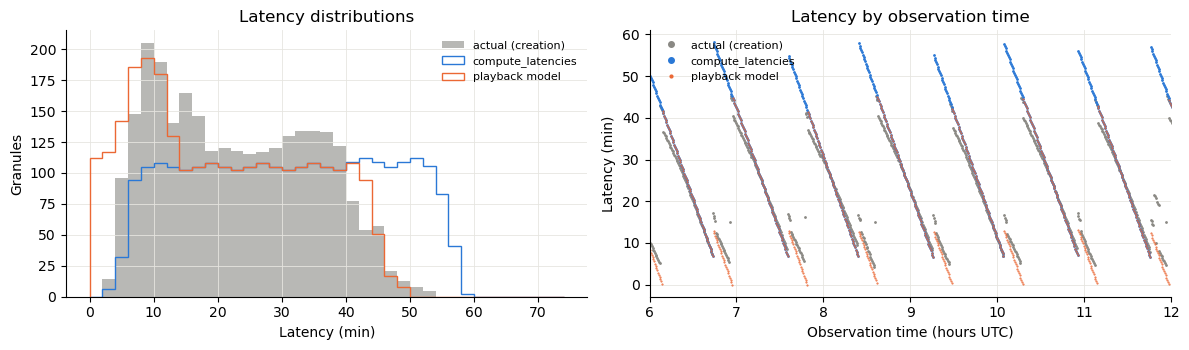

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
bins = np.arange(0, 75, 2)
axes[0].hist(np.clip(actual, 0, 74), bins=bins, color=GRAY, alpha=0.6, label="actual (creation)")
axes[0].hist(np.clip(tatc, 0, 74), bins=bins, histtype="step", color=BLUE, lw=1.5, label="compute_latencies")
axes[0].hist(np.clip(playback, 0, 74), bins=bins, histtype="step", color=ORANGE, lw=1.5, label="playback model")
axes[0].set(xlabel="Latency (min)", ylabel="Granules", title="Latency distributions")
axes[0].legend(frameon=False, fontsize=8)
hours = [(t - DAY) / timedelta(hours=1) for t in granules.end]
axes[1].plot(hours, actual, ".", ms=2, color=GRAY, label="actual (creation)")
axes[1].plot(hours, tatc, ".", ms=2, color=BLUE, label="compute_latencies")
axes[1].plot(hours, playback, ".", ms=1, color=ORANGE, label="playback model")
axes[1].set(xlim=(6, 12), xlabel="Observation time (hours UTC)", ylabel="Latency (min)", title="Latency by observation time")
axes[1].legend(frameon=False, fontsize=8, markerscale=4)
fig.tight_layout()
plt.show()

NOAA-20's ATMS data reaches users in 23 minutes on average (median 22 minutes, 95th percentile 43 minutes, from observation end to granule creation). `compute_latencies` reproduces the latency of the granules observed before a contact (mean 25.4 minutes, versus 25.6 minutes): the contact midpoint it uses happens to fall about when their processed granules are created (6 minutes after the contact starts). It assigns the granules observed during a contact to the next contact, however, so their latency is 51 minutes instead of 15, which raises the mean latency to 31 minutes and the per-granule error to 44 minutes (95th percentile).

The playback model, which delivers data observed during a contact at its end, reproduces the latency distribution (mean 21 minutes) to within 9 minutes per granule (95th percentile); the remaining difference is the processing time after the contact, which TAT-C does not model.

## Summary

| Test | Result |
| --- | --- |
| 1. Ground station contacts (`collect_downlinks`) | NOAA-20 downlinks at Svalbard and McMurdo; every granule is created after the start of a predicted contact, 96% within 20 minutes |
| 2. Downlink timing | data observed before a contact is created 3 to 7 minutes after it starts; data observed during a contact after it ends |
| 3. Latency (`compute_latencies`) | correct for data observed before a contact (25.4 versus 25.6 minutes); 36 minutes too long for the 23% of data observed during a contact (mean 31 versus 23 minutes) |

**Contacts.** TAT-C's predicted ground station contacts explain when NOAA-20's data is downlinked: no granule is created before a predicted contact starts, and nearly all within minutes of it.

**Latency.** `compute_latencies` pairs an observation with the first contact that starts after it, so data observed while the satellite is in contact waits for the next contact. For NOAA-20, whose stations see it for about 12 of every 50 minutes, this overestimates the mean latency by a third. Pairing such data with the end of the current contact, as NOAA-20's data flow does, would reproduce the observed latencies to within the processing time; this could be offered as an option of `compute_latencies`.